In [1]:
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder


In [4]:
!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]━━ 1/2 [openpyxl]


In [5]:
#============================================================
# 2. LOAD DATASET
# ============================================================

file_path = "Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

Dataset loaded successfully!
Shape: (541909, 8)

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
# ============================================================
# 3. DATA PREPROCESSING
# ============================================================

print("\nMissing values before preprocessing:")
print(df.isnull().sum())

# Remove rows where CustomerID is missing
df = df.dropna(subset=["CustomerID"])

# Remove cancelled transactions
# In Online Retail, invoices beginning with 'C' represent cancellations
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove invalid quantities
df = df[df["Quantity"] > 0]

# Remove invalid/zero prices
df = df[df["UnitPrice"] > 0]

# Convert CustomerID to integer
df["CustomerID"] = df["CustomerID"].astype(int)

# Calculate amount spent for each transaction
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

print("\nShape after preprocessing:", df.shape)

print("\nCleaned dataset:")
display(df.head())


Missing values before preprocessing:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Shape after preprocessing: (397884, 9)

Cleaned dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [7]:
# ============================================================
# 4. CONVERT TRANSACTION-LEVEL DATA
#    INTO CUSTOMER-LEVEL DATA
# ============================================================

customer_data = df.groupby("CustomerID").agg(
    Total_Spending=("TotalAmount", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Number_of_Purchases=("InvoiceNo", "nunique"),
    Number_of_Products=("StockCode", "nunique")
).reset_index()

print("\nCustomer-level dataset:")
display(customer_data.head())

print("\nNumber of customers:", len(customer_data))


Customer-level dataset:


,CustomerID,Total_Spending,Total_Quantity,Number_of_Purchases,Number_of_Products
0,12346,77183.60,74215,1,1
1,12347,4310.00,2458,7,103
2,12348,1797.24,2341,4,22
3,12349,1757.55,631,1,73
4,12350,334.40,197,1,17



Number of customers: 4338


In [8]:
# ============================================================
# 5. CREATE CUSTOMER CATEGORIES
# ============================================================
# We create three categories:
#
# Low Value Customer
# Medium Value Customer
# High Value Customer
#
# based on Total Spending.
#
# qcut divides customers into approximately equal-sized groups.

customer_data["Customer_Category"] = pd.qcut(
    customer_data["Total_Spending"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"],
    duplicates="drop"
)

print("\nCustomer category distribution:")
print(customer_data["Customer_Category"].value_counts())


Customer category distribution:
Customer_Category
Low Value       1446
Medium Value    1446
High Value      1446
Name: count, dtype: int64


In [9]:
# ============================================================
# 6. SELECT FEATURES
# ============================================================

features = [
    "Total_Quantity",
    "Number_of_Purchases",
    "Number_of_Products"
]

X = customer_data[features].copy()

y = customer_data["Customer_Category"].astype(str).copy()

print("\nFeatures:")
display(X.head())

print("\nTarget:")
display(y.head())


Features:


,Total_Quantity,Number_of_Purchases,Number_of_Products
0,74215,1,1
1,2458,7,103
2,2341,4,22
3,631,1,73
4,197,1,17



Target:


0    High Value
1    High Value
2    High Value
3    High Value
4     Low Value
Name: Customer_Category, dtype: object

In [10]:
# ============================================================
# 7. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 3470
Testing samples: 868


In [11]:
# ============================================================
# 8. ENTROPY FUNCTION
# ============================================================

def entropy(y):
    """
    Calculate entropy of a target variable.
    """

    if len(y) == 0:
        return 0

    counts = Counter(y)
    probabilities = [
        count / len(y)
        for count in counts.values()
    ]

    entropy_value = 0

    for p in probabilities:
        if p > 0:
            entropy_value -= p * np.log2(p)

    return entropy_value

In [12]:
# ============================================================
# 9. INFORMATION GAIN
# ============================================================

def information_gain(X, y, feature, threshold):
    """
    Calculate information gain for a numerical feature
    using a threshold.
    """

    parent_entropy = entropy(y)

    left_mask = X[feature] <= threshold
    right_mask = X[feature] > threshold

    left_y = y[left_mask]
    right_y = y[right_mask]

    # If one side is empty, this is not a valid split
    if len(left_y) == 0 or len(right_y) == 0:
        return 0

    n = len(y)

    weighted_entropy = (
        (len(left_y) / n) * entropy(left_y)
        +
        (len(right_y) / n) * entropy(right_y)
    )

    gain = parent_entropy - weighted_entropy

    return gain


In [13]:
# ============================================================
# 10. FIND BEST SPLIT
# ============================================================

def find_best_split(X, y):

    best_feature = None
    best_threshold = None
    best_gain = -1

    for feature in X.columns:

        values = sorted(X[feature].unique())

        # Generate candidate thresholds
        if len(values) > 50:
            thresholds = np.percentile(
                values,
                np.linspace(5, 95, 20)
            )
            thresholds = np.unique(thresholds)
        else:
            thresholds = [
                (values[i] + values[i + 1]) / 2
                for i in range(len(values) - 1)
            ]

        for threshold in thresholds:

            gain = information_gain(
                X,
                y,
                feature,
                threshold
            )

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold, best_gain


In [14]:
# ============================================================
# 11. ID3 TREE NODE
# ============================================================

class Node:

    def __init__(
        self,
        feature=None,
        threshold=None,
        left=None,
        right=None,
        value=None,
        gain=0
    ):

        self.feature = feature
        self.threshold = threshold

        self.left = left
        self.right = right

        self.value = value

        self.gain = gain


# ============================================================
# 12. BUILD ID3 TREE
# ============================================================

def build_tree(
    X,
    y,
    depth=0,
    max_depth=5,
    min_samples=10
):

    # If all samples belong to the same class
    if len(set(y)) == 1:

        return Node(
            value=y.iloc[0]
        )

    # If dataset is too small
    if len(y) < min_samples:

        majority_class = Counter(y).most_common(1)[0][0]

        return Node(
            value=majority_class
        )

    # Stop if maximum depth reached
    if depth >= max_depth:

        majority_class = Counter(y).most_common(1)[0][0]

        return Node(
            value=majority_class
        )

    # Find best split
    feature, threshold, gain = find_best_split(X, y)

    # If no useful split exists
    if feature is None or gain <= 0:

        majority_class = Counter(y).most_common(1)[0][0]

        return Node(
            value=majority_class
        )

    # Split dataset
    left_mask = X[feature] <= threshold
    right_mask = X[feature] > threshold

    X_left = X[left_mask]
    y_left = y[left_mask]

    X_right = X[right_mask]
    y_right = y[right_mask]

    # Recursively build left subtree
    left_child = build_tree(
        X_left,
        y_left,
        depth + 1,
        max_depth,
        min_samples
    )

    # Recursively build right subtree
    right_child = build_tree(
        X_right,
        y_right,
        depth + 1,
        max_depth,
        min_samples
    )

    return Node(
        feature=feature,
        threshold=threshold,
        left=left_child,
        right=right_child,
        gain=gain
    )

In [15]:
# ============================================================
# 13. TRAIN ID3 MODEL
# ============================================================

print("\nBuilding ID3 Decision Tree...")

tree = build_tree(
    X_train,
    y_train,
    max_depth=5,
    min_samples=10
)

print("ID3 tree built successfully!")



Building ID3 Decision Tree...
ID3 tree built successfully!


In [16]:
# ============================================================
# 14. PRINT TREE STRUCTURE
# ============================================================

def print_tree(node, depth=0):

    indentation = "    " * depth

    if node.value is not None:

        print(
            indentation +
            "Leaf → " +
            str(node.value)
        )

        return

    print(
        indentation +
        f"[{node.feature} <= {node.threshold:.2f}] "
        f"(Information Gain = {node.gain:.4f})"
    )

    print(indentation + "├── True:")

    print_tree(
        node.left,
        depth + 1
    )

    print(indentation + "└── False:")

    print_tree(
        node.right,
        depth + 1
    )


print("\n==============================")
print("ID3 DECISION TREE")
print("==============================")

print_tree(tree)




ID3 DECISION TREE
[Total_Quantity <= 556.38] (Information Gain = 0.5868)
├── True:
    [Total_Quantity <= 206.09] (Information Gain = 0.3274)
    ├── True:
        [Total_Quantity <= 109.26] (Information Gain = 0.0631)
        ├── True:
            [Number_of_Purchases <= 1.50] (Information Gain = 0.0215)
            ├── True:
                [Total_Quantity <= 78.88] (Information Gain = 0.0097)
                ├── True:
                    Leaf → Low Value
                └── False:
                    Leaf → Low Value
            └── False:
                [Number_of_Products <= 24.50] (Information Gain = 0.0455)
                ├── True:
                    Leaf → Low Value
                └── False:
                    Leaf → Low Value
        └── False:
            [Number_of_Purchases <= 2.50] (Information Gain = 0.0776)
            ├── True:
                [Total_Quantity <= 173.58] (Information Gain = 0.0234)
                ├── True:
                    Leaf → Low Value
    

In [17]:

# ============================================================
# 15. PREDICTION FUNCTION
# ============================================================

def predict_one(node, row):

    # If leaf
    if node.value is not None:
        return node.value

    if row[node.feature] <= node.threshold:

        return predict_one(
            node.left,
            row
        )

    else:

        return predict_one(
            node.right,
            row
        )


def predict(tree, X):

    predictions = []

    for _, row in X.iterrows():

        predictions.append(
            predict_one(tree, row)
        )

    return predictions



In [18]:
# ============================================================
# 16. MAKE PREDICTIONS
# ============================================================

y_pred = predict(
    tree,
    X_test
)

print("\nPredictions:")
print(y_pred[:20])


# ============================================================
# 17. MODEL ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)



Predictions:
['Low Value', 'Low Value', 'Low Value', 'Low Value', 'Medium Value', 'Low Value', 'Low Value', 'High Value', 'Low Value', 'Medium Value', 'Low Value', 'Medium Value', 'Medium Value', 'High Value', 'High Value', 'High Value', 'Low Value', 'Low Value', 'Medium Value', 'Low Value']

MODEL PERFORMANCE
Accuracy: 82.72%

Classification Report:
              precision    recall  f1-score   support

  High Value       0.88      0.90      0.89       289
   Low Value       0.84      0.85      0.84       289
Medium Value       0.76      0.74      0.75       290

    accuracy                           0.83       868
   macro avg       0.83      0.83      0.83       868
weighted avg       0.83      0.83      0.83       868



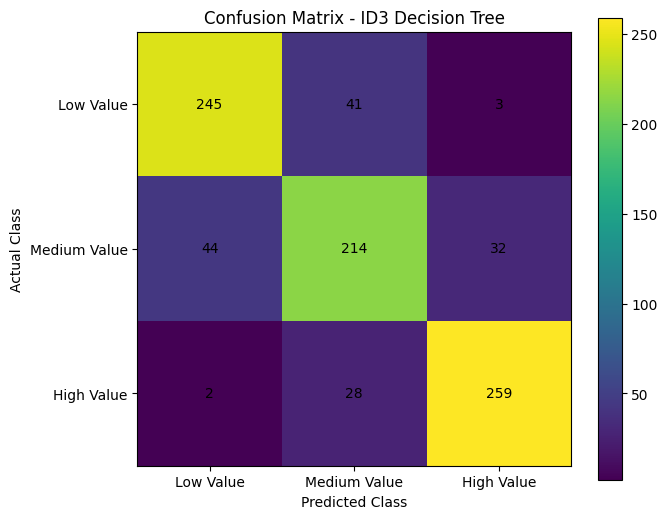

In [19]:
# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value"
    ]
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("Confusion Matrix - ID3 Decision Tree")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(3),
    ["Low Value", "Medium Value", "High Value"]
)

plt.yticks(
    range(3),
    ["Low Value", "Medium Value", "High Value"]
)

for i in range(3):
    for j in range(3):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()




FEATURE IMPORTANCE
Total_Quantity: 0.5901
Number_of_Purchases: 0.2119
Number_of_Products: 0.1980


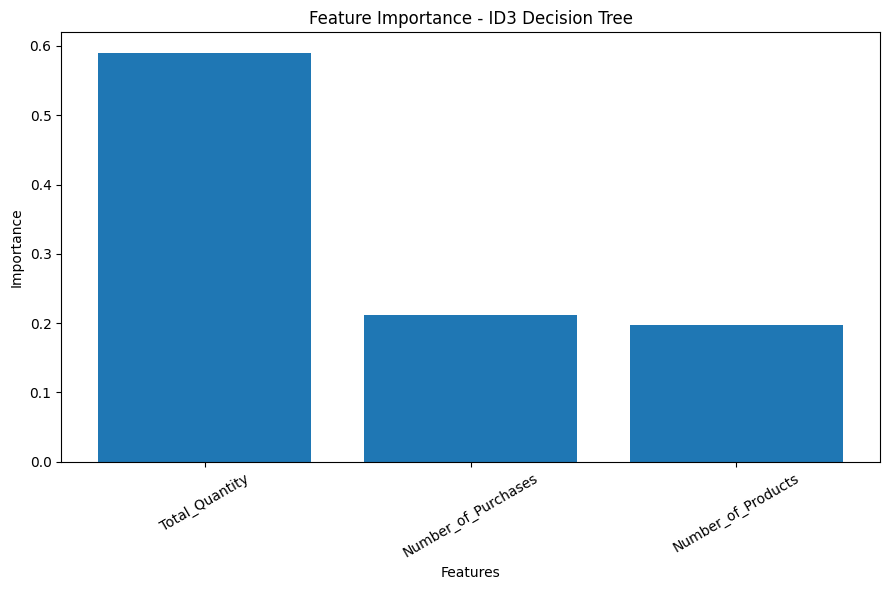

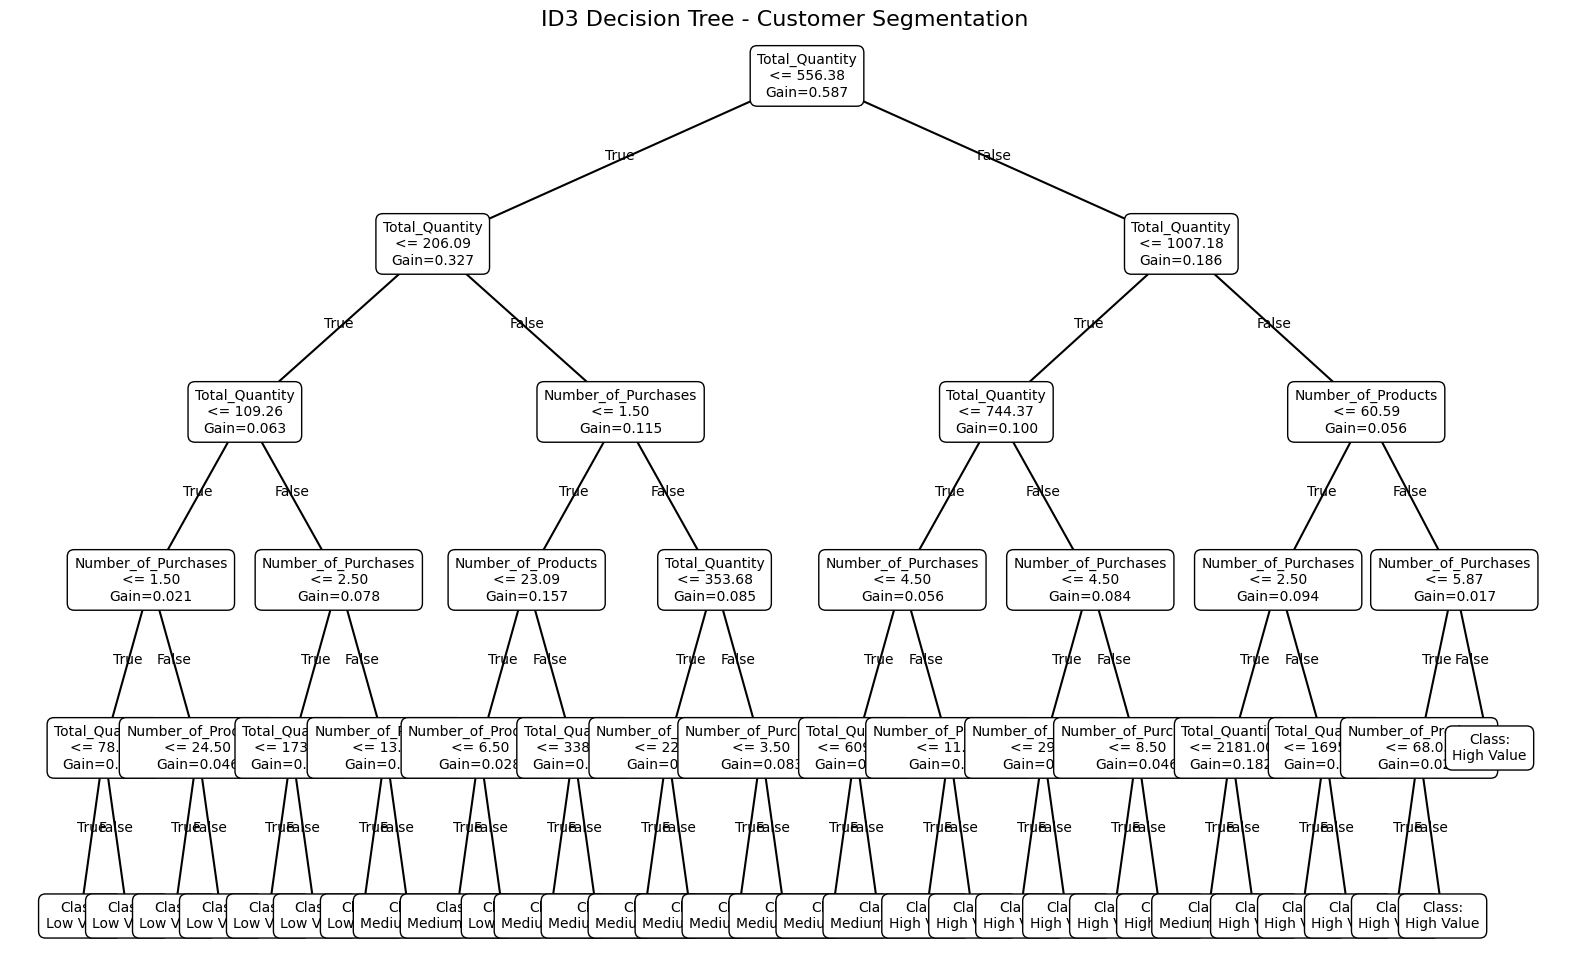


CUSTOMER SEGMENTATION


,CustomerID,Total_Spending,Total_Quantity,Number_of_Purchases,Number_of_Products,Customer_Category
0,12346,77183.60,74215,1,1,High Value
1,12347,4310.00,2458,7,103,High Value
2,12348,1797.24,2341,4,22,High Value
3,12349,1757.55,631,1,73,High Value
4,12350,334.40,197,1,17,Low Value
5,12352,2506.04,536,8,59,High Value
6,12353,89.00,20,1,4,Low Value
7,12354,1079.40,530,1,58,Medium Value
8,12355,459.40,240,1,13,Medium Value
9,12356,2811.43,1591,3,53,High Value



CATEGORY STATISTICS


,Total_Spending,Total_Quantity,Number_of_Purchases,Number_of_Products
Customer_Category,,,,
Low Value,220.600906,142.633472,1.325035,18.644537
Medium Value,712.587284,433.367911,2.573997,46.256570
High Value,5229.611190,2997.865837,8.917012,119.602351



DECISION RULES
IF Total_Quantity <= 556.38 AND Total_Quantity <= 206.09 AND Total_Quantity <= 109.26 AND Number_of_Purchases <= 1.50 AND Total_Quantity <= 78.88 THEN Customer Category = Low Value
IF Total_Quantity <= 556.38 AND Total_Quantity <= 206.09 AND Total_Quantity <= 109.26 AND Number_of_Purchases <= 1.50 AND Total_Quantity > 78.88 THEN Customer Category = Low Value
IF Total_Quantity <= 556.38 AND Total_Quantity <= 206.09 AND Total_Quantity <= 109.26 AND Number_of_Purchases > 1.50 AND Number_of_Products <= 24.50 THEN Customer Category = Low Value
IF Total_Quantity <= 556.38 AND Total_Quantity <= 206.09 AND Total_Quantity <= 109.26 AND Number_of_Purchases > 1.50 AND Number_of_Products > 24.50 THEN Customer Category = Low Value
IF Total_Quantity <= 556.38 AND Total_Quantity <= 206.09 AND Total_Quantity > 109.26 AND Number_of_Purchases <= 2.50 AND Total_Quantity <= 173.58 THEN Customer Category = Low Value
IF Total_Quantity <= 556.38 AND Total_Quantity <= 206.09 AND Total_Quantity

In [20]:

# ============================================================
# 19. FEATURE IMPORTANCE
# ============================================================

feature_importance = {
    feature: 0
    for feature in features
}


def calculate_feature_importance(
    node,
    importance
):

    if node is None or node.value is not None:
        return

    importance[node.feature] += node.gain

    calculate_feature_importance(
        node.left,
        importance
    )

    calculate_feature_importance(
        node.right,
        importance
    )


calculate_feature_importance(
    tree,
    feature_importance
)


# Normalize importance

total_importance = sum(
    feature_importance.values()
)

if total_importance > 0:

    for feature in feature_importance:

        feature_importance[feature] /= total_importance


print("\n==============================")
print("FEATURE IMPORTANCE")
print("==============================")

for feature, importance in sorted(
    feature_importance.items(),
    key=lambda x: x[1],
    reverse=True
):

    print(
        f"{feature}: {importance:.4f}"
    )


# ============================================================
# 20. FEATURE IMPORTANCE GRAPH
# ============================================================

importance_df = pd.DataFrame(
    {
        "Feature": list(feature_importance.keys()),
        "Importance": list(feature_importance.values())
    }
)

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(9, 6))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title(
    "Feature Importance - ID3 Decision Tree"
)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.show()


# ============================================================
# 21. VISUALIZE TREE AS A GRAPH
# ============================================================

# We create our own graph using matplotlib.
# This avoids relying on sklearn's DecisionTree plot,
# because our model is implemented from scratch.

fig, ax = plt.subplots(
    figsize=(20, 12)
)

ax.axis("off")


# Store positions
positions = {}
leaf_counter = [0]


def assign_positions(
    node,
    depth=0,
    x=0
):

    if node is None:
        return

    if node.value is not None:

        positions[id(node)] = (
            leaf_counter[0],
            -depth
        )

        leaf_counter[0] += 1

        return

    assign_positions(
        node.left,
        depth + 1,
        x
    )

    assign_positions(
        node.right,
        depth + 1,
        x
    )

    left_pos = positions[id(node.left)]
    right_pos = positions[id(node.right)]

    center_x = (
        left_pos[0] +
        right_pos[0]
    ) / 2

    positions[id(node)] = (
        center_x,
        -depth
    )


assign_positions(tree)


# Scale x positions
max_x = max(
    pos[0]
    for pos in positions.values()
)

if max_x == 0:
    max_x = 1


def draw_tree(node):

    if node is None:
        return

    x, y = positions[id(node)]

    x = x / max_x * 18
    y = y * 2

    if node.value is not None:

        ax.text(
            x,
            y,
            f"Class:\n{node.value}",
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.5",
                facecolor="white",
                edgecolor="black"
            )
        )

        return

    # Draw left child
    child_x, child_y = positions[id(node.left)]

    child_x = child_x / max_x * 18
    child_y = child_y * 2

    ax.plot(
        [x, child_x],
        [y, child_y],
        "k-"
    )

    ax.text(
        (x + child_x) / 2,
        (y + child_y) / 2,
        "True",
        ha="center"
    )

    # Draw right child
    child_x, child_y = positions[id(node.right)]

    child_x = child_x / max_x * 18
    child_y = child_y * 2

    ax.plot(
        [x, child_x],
        [y, child_y],
        "k-"
    )

    ax.text(
        (x + child_x) / 2,
        (y + child_y) / 2,
        "False",
        ha="center"
    )

    # Draw current node
    ax.text(
        x,
        y,
        f"{node.feature}\n<= {node.threshold:.2f}\nGain={node.gain:.3f}",
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="white",
            edgecolor="black"
        )
    )

    draw_tree(node.left)
    draw_tree(node.right)


draw_tree(tree)

plt.title(
    "ID3 Decision Tree - Customer Segmentation",
    fontsize=16
)

plt.show()


# ============================================================
# 22. DISPLAY CUSTOMER DATA WITH CATEGORIES
# ============================================================

print("\n==============================")
print("CUSTOMER SEGMENTATION")
print("==============================")

display(
    customer_data[
        [
            "CustomerID",
            "Total_Spending",
            "Total_Quantity",
            "Number_of_Purchases",
            "Number_of_Products",
            "Customer_Category"
        ]
    ].head(20)
)


# ============================================================
# 23. DISPLAY CATEGORY STATISTICS
# ============================================================

print("\n==============================")
print("CATEGORY STATISTICS")
print("==============================")

category_stats = customer_data.groupby(
    "Customer_Category",
    observed=True
)[
    [
        "Total_Spending",
        "Total_Quantity",
        "Number_of_Purchases",
        "Number_of_Products"
    ]
].mean()

display(category_stats)




In [22]:
# ============================================================
# BEAUTIFIED DECISION RULES
# ============================================================

def print_beautiful_rules(node, conditions=None, rule_no=[1]):

    if conditions is None:
        conditions = []

    # Leaf node
    if node.value is not None:

        print(f"\nRule {rule_no[0]}:")
        
        if conditions:
            for condition in conditions:
                print(f"   • {condition}")
        
        print(f"   → Customer Category = {node.value}")

        rule_no[0] += 1
        return

    # Left branch
    left_condition = (
        f"{node.feature} ≤ {node.threshold:.2f}"
    )

    print_beautiful_rules(
        node.left,
        conditions + [left_condition],
        rule_no
    )

    # Right branch
    right_condition = (
        f"{node.feature} > {node.threshold:.2f}"
    )

    print_beautiful_rules(
        node.right,
        conditions + [right_condition],
        rule_no
    )


print("\n" + "=" * 70)
print("               ID3 DECISION RULES")
print("=" * 70)

print_beautiful_rules(tree)

print("\n" + "=" * 70)


               ID3 DECISION RULES

Rule 1:
   • Total_Quantity ≤ 556.38
   • Total_Quantity ≤ 206.09
   • Total_Quantity ≤ 109.26
   • Number_of_Purchases ≤ 1.50
   • Total_Quantity ≤ 78.88
   → Customer Category = Low Value

Rule 2:
   • Total_Quantity ≤ 556.38
   • Total_Quantity ≤ 206.09
   • Total_Quantity ≤ 109.26
   • Number_of_Purchases ≤ 1.50
   • Total_Quantity > 78.88
   → Customer Category = Low Value

Rule 3:
   • Total_Quantity ≤ 556.38
   • Total_Quantity ≤ 206.09
   • Total_Quantity ≤ 109.26
   • Number_of_Purchases > 1.50
   • Number_of_Products ≤ 24.50
   → Customer Category = Low Value

Rule 4:
   • Total_Quantity ≤ 556.38
   • Total_Quantity ≤ 206.09
   • Total_Quantity ≤ 109.26
   • Number_of_Purchases > 1.50
   • Number_of_Products > 24.50
   → Customer Category = Low Value

Rule 5:
   • Total_Quantity ≤ 556.38
   • Total_Quantity ≤ 206.09
   • Total_Quantity > 109.26
   • Number_of_Purchases ≤ 2.50
   • Total_Quantity ≤ 173.58
   → Customer Category = Low Value

